# Test file for CIC-IDS2017 model creation and analysis

### 1. Data loading

In [25]:
import pandas as pd
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

pd.options.display.max_rows = 80

In [2]:
# read data

#get dataset size for comparison
file_path = '/mnt/AI-DATA/alara/CiberIA_O1_A1/Data/CIC-IDS2018.csv'
file_size = os.path.getsize(file_path)
print(f"Dataset size: {file_size / (1024 * 1024):.2f} MB")

start_time = datetime.now()
print("Reading data with Polars...")
df_pl = pl.read_csv(file_path, low_memory=False)
print("Data read using Polars in", datetime.now() - start_time) 

Dataset size: 7614.26 MB
Reading data with Polars...
Data read using Polars in 0:00:01.599753


In [3]:
start_time = datetime.now()
print("Reading data with Polars...")
df_pl = pl.read_csv(file_path, low_memory=False)
print("Data read using Polars in", datetime.now() - start_time) 

Reading data with Polars...
Data read using Polars in 0:00:01.629275


### 2. Data exploration

In [4]:
from IPython.display import display
#display(df_pd.head())
display(df_pl.head())

Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,…,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0,0.0,"""2018-03-01 08:17:11""",1.15307855e8,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.043362,2.88e7,3.24e7,6.1e7,812396.0,1.15e8,2.88e7,3.24e7,6.1e7,812396.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.812348e6,0.0,1.812348e6,1.812348e6,5.67e7,6.0101e6,6.1e7,5.25e7,"""Benign"""
0,0.0,"""2018-03-01 08:20:07""",6.0997457e7,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.032788,6.1e7,0.0,6.1e7,6.1e7,6.1e7,6.1e7,0.0,6.1e7,6.1e7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.1e7,0.0,6.1e7,6.1e7,"""Benign"""
67,17.0,"""2018-03-01 08:17:18""",6.1149019e7,5.0,0.0,1500.0,0.0,300.0,300.0,300.0,0.0,0.0,0.0,0.0,0.0,24.530238,0.081767,1.53e7,1.28e7,3.26e7,3.530939e6,6.11e7,1.53e7,1.28e7,3.26e7,3.530939e6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,360.0,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1500.0,0.0,0.0,-1.0,-1.0,4.0,8.0,3.530939e6,0.0,3.530939e6,3.530939e6,1.92e7,1.25e7,3.26e7,7.999725e6,"""Benign"""
0,0.0,"""2018-03-01 08:22:09""",6.0997555e7,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.032788,6.1e7,0.0,6.1e7,6.1e7,6.1e7,6.1e7,0.0,6.1e7,6.1e7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.1e7,0.0,6.1e7,6.1e7,"""Benign"""
0,0.0,"""2018-03-01 08:24:11""",6.1997503e7,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.048389,3.1e7,4.24e7,6.1e7,999909.0,6.2e7,3.1e7,4.24e7,6.1e7,999909.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,999909.0,0.0,999909.0,999909.0,6.1e7,0.0,6.1e7,6.1e7,"""Benign"""


In [5]:
start_time = datetime.now()
print("Converting Polars DataFrame to Pandas DataFrame...")

try:
    df = df_pl.to_pandas()
    print("Conversion completed in", datetime.now() - start_time)
except Exception as e:
    print("Conversion failed:", e)

Converting Polars DataFrame to Pandas DataFrame...
Conversion completed in 0:00:01.226998


In [6]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (15799748, 80)
Nombre columnas: Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag C

In [7]:
attack_map = {
    'Benign': 'BENIGN',
    'DDOS attack-HOIC': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DoS attacks-Hulk': 'DoS',
    'Bot': 'Bot',
    'Infilteration': 'Infiltration',
    'SSH-Bruteforce': 'Brute Force',
    'DoS attacks-GoldenEye': 'DoS',
    'FTP-BruteForce': 'Brute Force',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'Brute Force -Web': 'Brute Force',
    'Brute Force -XSS': 'Brute Force',
    'SQL Injection': 'Injection'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label'].map(attack_map)
df.drop('Label', axis = 1, inplace = True)

# remove 'Injection' class
df = df[~df['Attack Type'].isin(['Injection'])]
print("Data shape:", df.shape)
print("Data columns:", df.columns)

print("Encoding attack types...")
le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])
print("Encoded attack classes:")
for val in sorted(df['Attack Number'].unique()):
    print(f"{val}: {le.inverse_transform([val])[0]}")

print("Number of samples of each attack type:")
print(df['Attack Type'].value_counts())

print("Reducing memory usage...")
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)
new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

data = df.copy()

attacks = data['Attack Type']
data = data.select_dtypes(include=['float32', 'int32'])

selected_columns = [
    'Dst Port', 'Protocol', 'Flow Duration',
    'Bwd Pkt Len Max', 'Bwd Pkt Len Min',
    'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow IAT Mean',
    'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Tot', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max',
    'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
    'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt',
    'PSH Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio',
    'Pkt Size Avg', 'Bwd Seg Size Avg', 'Init Fwd Win Byts',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
data = data[selected_columns]

#change the column names

data.columns = ['Destination Port', 'Protocol', 'Flow Duration',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Avg Bwd Segment Size', 'Init_Win_bytes_forward',
       'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

print("Standardizing features...")
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data)

Data shape: (15799661, 80)
Data columns: Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt'

In [8]:
# save selected features
new_data_k_20 = data.copy()
new_data_k_20['Attack Type'] = attacks.values

print(new_data_k_20.head())

   Destination Port  Protocol  Flow Duration  Bwd Packet Length Max  \
0                 0       0.0    115307856.0                    0.0   
1                 0       0.0     60997456.0                    0.0   
2                67      17.0     61149020.0                    0.0   
3                 0       0.0     60997556.0                    0.0   
4                 0       0.0     61997504.0                    0.0   

   Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  \
0                    0.0                     0.0                    0.0   
1                    0.0                     0.0                    0.0   
2                    0.0                     0.0                    0.0   
3                    0.0                     0.0                    0.0   
4                    0.0                     0.0                    0.0   

   Flow IAT Mean  Flow IAT Std  Flow IAT Max  ...  ACK Flag Count  \
0     28800000.0    32400000.0    61000000.0  ...    

In [9]:
from imblearn.over_sampling import SMOTE

#######################################################################

class_counts = new_data_k_20['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data_k_20[new_data_k_20['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 10000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.3, random_state = 0)

In [10]:
# save X_train, X_test, y_train, y_test in a variable
data_split = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
# save the data_split variable to a file
import pickle
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2018.pkl', 'wb') as f:
    pickle.dump(data_split, f)

In [33]:
import joblib
import joblib
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# load data_split from 2017 and 2018 and combine into new X_train, X_test, y_train, y_test using 70% and 30% of the data
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2017.pkl', 'rb') as f:
    data_split_2017 = pickle.load(f)
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2018.pkl', 'rb') as f:
    data_split_2018 = pickle.load(f)
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_unsw.pkl', 'rb') as f:
    data_split_unsw = pickle.load(f)

results = {}

percentage_series = [{
    '2017': 100,
    '2018': 0,
    'unsw': 0
}, {
    '2017': 80,
    '2018': 20,
    'unsw': 0
}, {
    '2017': 60,
    '2018': 40,
    'unsw': 0
},{
    '2017': 40,
    '2018': 60,
    'unsw': 0
},{
    '2017': 20,
    '2018': 80,
    'unsw': 0
},{
    '2017': 0,
    '2018': 100,
    'unsw': 0
},{
    '2017': 0,
    '2018': 80,
    'unsw': 20
},{
    '2017': 0,
    '2018': 60,
    'unsw': 40
},{
    '2017': 0,
    '2018': 40,
    'unsw': 60
},{
    '2017': 0,
    '2018': 20,
    'unsw': 80
},{
    '2017': 0,
    '2018': 0,
    'unsw': 100
}]

for i in range(1, 11):
    print(f"Processing fold {i}...")

    # Load the model for the current fold
    model_filename = f'/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_original.pkl'
    stacked_clf = joblib.load(model_filename)

    percentage_2017 = percentage_series[i-1]['2017']
    percentage_2018 = percentage_series[i-1]['2018']
    percentage_unsw = percentage_series[i-1]['unsw']

    print(f"Using {percentage_2017}% of 2017 data, {percentage_2018}% of 2018 data, and {percentage_unsw}% of UNSW data.")

    # Calculate the number of samples for each dataset
    n_samples_2017 = int(len(data_split_2017['X_test']) * percentage_2017 / 100)
    n_samples_2018 = int(len(data_split_2018['X_test']) * percentage_2018 / 100)
    n_samples_unsw = int(len(data_split_unsw['X_test']) * percentage_unsw / 100)


    X_test = pd.concat([
        data_split_2017['X_test'].sample(n=n_samples_2017, random_state=42),
        data_split_2018['X_test'].sample(n=n_samples_2018, random_state=42),
        data_split_unsw['X_test'].sample(n=n_samples_unsw, random_state=42)
    ], ignore_index=True)

    y_test = pd.concat([
        data_split_2017['y_test'].sample(n=n_samples_2017, random_state=42),
        data_split_2018['y_test'].sample(n=n_samples_2018, random_state=42),
        data_split_unsw['y_test'].sample(n=n_samples_unsw, random_state=42)
    ], ignore_index=True)


    X_train = pd.concat([
        data_split_2017['X_train'].sample(n=int(len(data_split_2017['X_train']) * percentage_2017 / 100), random_state=42),
        data_split_2018['X_train'].sample(n=int(len(data_split_2018['X_train']) * percentage_2018 / 100), random_state=42),
        data_split_unsw['X_train'].sample(n=int(len(data_split_unsw['X_train']) * percentage_unsw / 100), random_state=42)
    ], ignore_index=True)

    y_train = pd.concat([
        data_split_2017['y_train'].sample(n=int(len(data_split_2017['y_train']) * percentage_2017 / 100), random_state=42),
        data_split_2018['y_train'].sample(n=int(len(data_split_2018['y_train']) * percentage_2018 / 100), random_state=42),
        data_split_unsw['y_train'].sample(n=int(len(data_split_unsw['y_train']) * percentage_unsw / 100), random_state=42)
    ], ignore_index=True)

    accuracy = stacked_clf.score(X_test, y_test)
    print(f"Original accuracy for fold {i}: {accuracy:.4f}")

    ACCURACY_THRESHOLD = 0.9
    training_time = 0.0  # Placeholder for training time, if needed

    if accuracy < ACCURACY_THRESHOLD:
        print(f"Accuracy {accuracy:.2f} < {ACCURACY_THRESHOLD:.2f}. Retraining model...")

        params = {
        'min_gain_to_split': 0.1,  # Lowering the threshold for splits
        'min_child_samples': 20,   # Preventing overfitting by controlling sample count per leaf
        'min_data_in_leaf': 30,    # Ensures enough data per leaf
        'num_leaves': 40,
        'max_depth': 15,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,  # Using a fraction of features to prevent overfitting
        'bagging_fraction': 0.8,  # Using a fraction of data to prevent overfitting
        'bagging_freq': 5,  # Perform bagging every iteration
        'random_state': 0,
        'verbose': -1
        }

        # a) Recreate the stacking pipeline (replace with your original base/stacker models)
        base_learners = [
            ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, criterion='gini', max_features='sqrt')),
            ('lgb', lgb.LGBMClassifier(**params))
        ]
        lr = LogisticRegression(max_iter=20000, C=1.0, penalty='l2', solver='lbfgs', random_state=0)
        meta_learner = lr
        
        # b) Build a new pipeline including scaling + stacking
        #    (Assumes X_train is already the appropriate feature set)
        scaler = StandardScaler()
        stacking = StackingClassifier(
            estimators=base_learners,
            final_estimator=meta_learner,
            cv=5,
            n_jobs=-1,
            passthrough=True
        )

        # Combine scaling and stacking into a single Pipeline
        retrain_pipeline = Pipeline([
            ('scaler', scaler),
            ('stacking', stacking)
        ])

        # c) Fit on the new(train) data
        time_start = datetime.now()
        retrain_pipeline.fit(X_train, y_train)
        training_time = (datetime.now() - time_start).total_seconds()
        new_accuracy = retrain_pipeline.score(X_test, y_test)
        print(f"Retrained model accuracy: {new_accuracy:.2f}")

        print(f"Retraining took {training_time:.2f} seconds.")

        # d) Save the newly trained model back to disk
        #joblib.dump(retrain_pipeline, model_filename)
        #print(f"Retrained model saved to {model_filename}")

    else:

        print("Accuracy is above threshold—no retraining needed.")
        training_time = 0.0
        print(f"Retraining took {training_time:.2f} seconds.")


    results[f'fold_{i}'] = {
        'percentage_2017': percentage_2017,
        'percentage_2018': percentage_2018,
        'percentage_unsw': percentage_unsw,
        'accuracy': accuracy,
        'retrained_accuracy': accuracy if accuracy >= ACCURACY_THRESHOLD else new_accuracy,
        'training_time': training_time
    }







Processing fold 1...
Using 100% of 2017 data, 0% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 1: 0.9980
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Processing fold 2...
Using 80% of 2017 data, 20% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 2: 0.8779
Accuracy 0.88 < 0.90. Retraining model...


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.97
Retraining took 34.13 seconds.
Processing fold 3...
Using 60% of 2017 data, 40% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 3: 0.7515
Accuracy 0.75 < 0.90. Retraining model...


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.96
Retraining took 33.21 seconds.
Processing fold 4...
Using 40% of 2017 data, 60% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 4: 0.6167
Accuracy 0.62 < 0.90. Retraining model...


...

/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.86
Retraining took 32.62 seconds.
Processing fold 10...
Using 0% of 2017 data, 20% of 2018 data, and 80% of UNSW data.
Original accuracy for fold 10: 0.1600
Accuracy 0.16 < 0.90. Retraining model...


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.86
Retraining took 30.76 seconds.


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
print("Results:")
for fold, result in results.items():
    print(f"{fold}: {result['percentage_2017']}% 2017, {result['percentage_2018']}% 2018, {result['percentage_unsw']}% UNSW - Accuracy: {result['accuracy']:.4f}, Retrained Accuracy: {result['retrained_accuracy']:.4f}, Training Time: {result['training_time']:.2f} seconds")


Results:
fold_1: 100% 2017, 0% 2018, 0% UNSW - Accuracy: 0.9980, Retrained Accuracy: 0.9980, Training Time: 0.00 seconds
fold_2: 80% 2017, 20% 2018, 0% UNSW - Accuracy: 0.8779, Retrained Accuracy: 0.9688, Training Time: 34.13 seconds
fold_3: 60% 2017, 40% 2018, 0% UNSW - Accuracy: 0.7515, Retrained Accuracy: 0.9576, Training Time: 33.21 seconds
fold_4: 40% 2017, 60% 2018, 0% UNSW - Accuracy: 0.6167, Retrained Accuracy: 0.9378, Training Time: 33.35 seconds
fold_5: 20% 2017, 80% 2018, 0% UNSW - Accuracy: 0.4743, Retrained Accuracy: 0.9182, Training Time: 34.27 seconds
fold_6: 0% 2017, 100% 2018, 0% UNSW - Accuracy: 0.3207, Retrained Accuracy: 0.8981, Training Time: 25.43 seconds
fold_7: 0% 2017, 80% 2018, 20% UNSW - Accuracy: 0.3029, Retrained Accuracy: 0.8873, Training Time: 35.72 seconds
fold_8: 0% 2017, 60% 2018, 40% UNSW - Accuracy: 0.2749, Retrained Accuracy: 0.8717, Training Time: 34.06 seconds
fold_9: 0% 2017, 40% 2018, 60% UNSW - Accuracy: 0.2341, Retrained Accuracy: 0.8600, Trai

In [37]:
import joblib
import joblib
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import pickle

# load data_split from 2017 and 2018 and combine into new X_train, X_test, y_train, y_test using 70% and 30% of the data
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2017.pkl', 'rb') as f:
    data_split_2017 = pickle.load(f)
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2018.pkl', 'rb') as f:
    data_split_2018 = pickle.load(f)
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_unsw.pkl', 'rb') as f:
    data_split_unsw = pickle.load(f)

results = {}

percentage_series = [{
    '2017': 100,
    '2018': 0,
    'unsw': 0
}, {
    '2017': 80,
    '2018': 20,
    'unsw': 0
}, {
    '2017': 60,
    '2018': 40,
    'unsw': 0
},{
    '2017': 40,
    '2018': 60,
    'unsw': 0
},{
    '2017': 20,
    '2018': 80,
    'unsw': 0
},{
    '2017': 0,
    '2018': 100,
    'unsw': 0
},{
    '2017': 0,
    '2018': 80,
    'unsw': 20
},{
    '2017': 0,
    '2018': 60,
    'unsw': 40
},{
    '2017': 0,
    '2018': 40,
    'unsw': 60
},{
    '2017': 0,
    '2018': 20,
    'unsw': 80
},{
    '2017': 0,
    '2018': 0,
    'unsw': 100
}]

retrained = False

for i in range(1, 11):
    print(f"Processing fold {i}...")

    if not retrained:
        # Load the model for the first fold
        model_filename = f'/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_original.pkl'
        stacked_clf = joblib.load(model_filename)
    else:
        # For subsequent folds, we will use the same model
        model_filename = f'/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl'
        stacked_clf = joblib.load(model_filename)

    print(f"**************Loaded model from {model_filename}***************")

    percentage_2017 = percentage_series[i-1]['2017']
    percentage_2018 = percentage_series[i-1]['2018']
    percentage_unsw = percentage_series[i-1]['unsw']

    print(f"Using {percentage_2017}% of 2017 data, {percentage_2018}% of 2018 data, and {percentage_unsw}% of UNSW data.")

    # Calculate the number of samples for each dataset
    n_samples_2017 = int(len(data_split_2017['X_test']) * percentage_2017 / 100)
    n_samples_2018 = int(len(data_split_2018['X_test']) * percentage_2018 / 100)
    n_samples_unsw = int(len(data_split_unsw['X_test']) * percentage_unsw / 100)

    X_test = pd.concat([
        data_split_2017['X_test'].sample(n=n_samples_2017, random_state=42),
        data_split_2018['X_test'].sample(n=n_samples_2018, random_state=42),
        data_split_unsw['X_test'].sample(n=n_samples_unsw, random_state=42)
    ], ignore_index=True)

    y_test = pd.concat([
        data_split_2017['y_test'].sample(n=n_samples_2017, random_state=42),
        data_split_2018['y_test'].sample(n=n_samples_2018, random_state=42),
        data_split_unsw['y_test'].sample(n=n_samples_unsw, random_state=42)
    ], ignore_index=True)


    X_train = pd.concat([
        data_split_2017['X_train'].sample(n=int(len(data_split_2017['X_train']) * percentage_2017 / 100), random_state=42),
        data_split_2018['X_train'].sample(n=int(len(data_split_2018['X_train']) * percentage_2018 / 100), random_state=42),
        data_split_unsw['X_train'].sample(n=int(len(data_split_unsw['X_train']) * percentage_unsw / 100), random_state=42)
    ], ignore_index=True)

    y_train = pd.concat([
        data_split_2017['y_train'].sample(n=int(len(data_split_2017['y_train']) * percentage_2017 / 100), random_state=42),
        data_split_2018['y_train'].sample(n=int(len(data_split_2018['y_train']) * percentage_2018 / 100), random_state=42),
        data_split_unsw['y_train'].sample(n=int(len(data_split_unsw['y_train']) * percentage_unsw / 100), random_state=42)
    ], ignore_index=True)

    accuracy = stacked_clf.score(X_test, y_test)
    print(f"Original accuracy for fold {i}: {accuracy:.4f}")

    ACCURACY_THRESHOLD = 0.85
    training_time = 0.0  # Placeholder for training time, if needed

    if accuracy < ACCURACY_THRESHOLD:
        print(f"Accuracy {accuracy:.2f} < {ACCURACY_THRESHOLD:.2f}. Retraining model...")

        params = {
        'min_gain_to_split': 0.1,  # Lowering the threshold for splits
        'min_child_samples': 20,   # Preventing overfitting by controlling sample count per leaf
        'min_data_in_leaf': 30,    # Ensures enough data per leaf
        'num_leaves': 40,
        'max_depth': 15,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,  # Using a fraction of features to prevent overfitting
        'bagging_fraction': 0.8,  # Using a fraction of data to prevent overfitting
        'bagging_freq': 5,  # Perform bagging every iteration
        'random_state': 0,
        'verbose': -1
        }

        # a) Recreate the stacking pipeline (replace with your original base/stacker models)
        base_learners = [
            ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, criterion='gini', max_features='sqrt')),
            ('lgb', lgb.LGBMClassifier(**params))
        ]
        lr = LogisticRegression(max_iter=20000, C=1.0, penalty='l2', solver='lbfgs', random_state=0)
        meta_learner = lr
        
        # b) Build a new pipeline including scaling + stacking
        #    (Assumes X_train is already the appropriate feature set)
        scaler = StandardScaler()
        stacking = StackingClassifier(
            estimators=base_learners,
            final_estimator=meta_learner,
            cv=5,
            n_jobs=-1,
            passthrough=True
        )

        # Combine scaling and stacking into a single Pipeline
        retrain_pipeline = Pipeline([
            ('scaler', scaler),
            ('stacking', stacking)
        ])

        # c) Fit on the new(train) data
        time_start = datetime.now()
        retrain_pipeline.fit(X_train, y_train)
        training_time = (datetime.now() - time_start).total_seconds()
        new_accuracy = retrain_pipeline.score(X_test, y_test)
        print(f"Retrained model accuracy: {new_accuracy:.2f}")

        print(f"Retraining took {training_time:.2f} seconds.")
        retrained = True

    else:

        print("Accuracy is above threshold—no retraining needed.")
        training_time = 0.0
        print(f"Retraining took {training_time:.2f} seconds.")

    if retrained:
        # d) Save the newly trained model back to disk
        model_filename = f'/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl'
        joblib.dump(retrain_pipeline, model_filename)
        print(f"Retrained model saved to {model_filename}")

    results[f'fold_{i}'] = {
        'percentage_2017': percentage_2017,
        'percentage_2018': percentage_2018,
        'percentage_unsw': percentage_unsw,
        'accuracy': accuracy,
        'retrained_accuracy': accuracy if accuracy >= ACCURACY_THRESHOLD else new_accuracy,
        'training_time': training_time
    }

Processing fold 1...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_original.pkl***************
Using 100% of 2017 data, 0% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 1: 0.9980
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Processing fold 2...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_original.pkl***************
Using 80% of 2017 data, 20% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 2: 0.8779
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Processing fold 3...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_original.pkl***************
Using 60% of 2017 data, 40% of 2018 data, and 0% of UNSW data.
Original accuracy for fold 3: 0.7515
Accuracy 0.75 < 0.85. Retraining model...


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.96
Retraining took 31.29 seconds.
Retrained model saved to /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl
Processing fold 4...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl***************
Using 40% of 2017 data, 60% of 2018 data, and 0% of UNSW data.


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Original accuracy for fold 4: 0.9340
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Retrained model saved to /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl
Processing fold 5...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl***************
Using 20% of 2017 data, 80% of 2018 data, and 0% of UNSW data.


...

Original accuracy for fold 8: 0.8714
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Retrained model saved to /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl
Processing fold 9...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl***************
Using 0% of 2017 data, 40% of 2018 data, and 60% of UNSW data.


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Original accuracy for fold 9: 0.8502
Accuracy is above threshold—no retraining needed.
Retraining took 0.00 seconds.
Retrained model saved to /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl
Processing fold 10...
**************Loaded model from /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl***************
Using 0% of 2017 data, 20% of 2018 data, and 80% of UNSW data.
Original accuracy for fold 10: 0.8152
Accuracy 0.82 < 0.85. Retraining model...


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not ha

Retrained model accuracy: 0.86
Retraining took 28.04 seconds.
Retrained model saved to /mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model_modified.pkl


In [36]:
print("Results:")
for fold, result in results.items():
    print(f"{fold}: {result['percentage_2017']}% 2017, {result['percentage_2018']}% 2018, {result['percentage_unsw']}% UNSW - Accuracy: {result['accuracy']:.4f}, Retrained Accuracy: {result['retrained_accuracy']:.4f}, Training Time: {result['training_time']:.2f} seconds")


Results:
fold_1: 100% 2017, 0% 2018, 0% UNSW - Accuracy: 0.9980, Retrained Accuracy: 0.9980, Training Time: 0.00 seconds
fold_2: 80% 2017, 20% 2018, 0% UNSW - Accuracy: 0.8779, Retrained Accuracy: 0.9684, Training Time: 33.35 seconds
fold_3: 60% 2017, 40% 2018, 0% UNSW - Accuracy: 0.9413, Retrained Accuracy: 0.9413, Training Time: 0.00 seconds
fold_4: 40% 2017, 60% 2018, 0% UNSW - Accuracy: 0.9137, Retrained Accuracy: 0.9137, Training Time: 0.00 seconds
fold_5: 20% 2017, 80% 2018, 0% UNSW - Accuracy: 0.8845, Retrained Accuracy: 0.9179, Training Time: 31.07 seconds
fold_6: 0% 2017, 100% 2018, 0% UNSW - Accuracy: 0.8959, Retrained Accuracy: 0.8989, Training Time: 24.73 seconds
fold_7: 0% 2017, 80% 2018, 20% UNSW - Accuracy: 0.8483, Retrained Accuracy: 0.8878, Training Time: 33.18 seconds
fold_8: 0% 2017, 60% 2018, 40% UNSW - Accuracy: 0.8719, Retrained Accuracy: 0.8724, Training Time: 31.95 seconds
fold_9: 0% 2017, 40% 2018, 60% UNSW - Accuracy: 0.8543, Retrained Accuracy: 0.8606, Traini

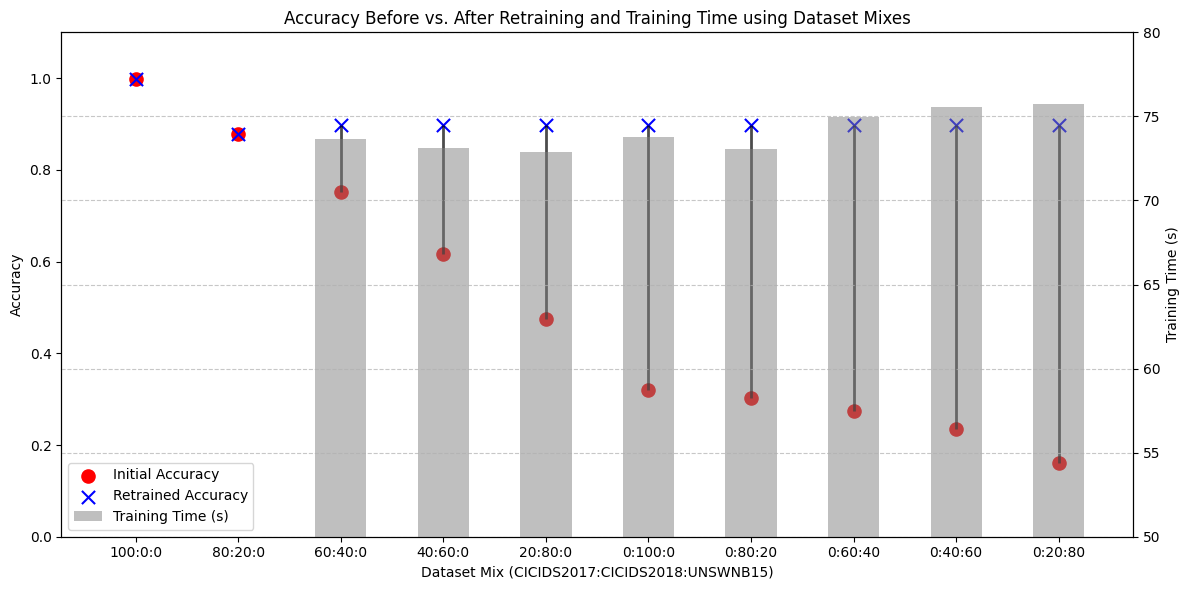

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
folds = [
    "100:0:0", "80:20:0", "60:40:0", "40:60:0", "20:80:0",
    "0:100:0", "0:80:20", "0:60:40", "0:40:60", "0:20:80"
]
initial_acc   = [0.9980, 0.8779, 0.7515, 0.6167, 0.4743, 0.3207, 0.3029, 0.2749, 0.2341, 0.1600]
retrained_acc = [0.9980, 0.8779, 0.8987, 0.8984, 0.8987, 0.8982, 0.8980, 0.8986, 0.8987, 0.8981]
train_time    = [0.00,   0.00,   73.68,  73.15,  72.89,  73.75,  73.07,  74.99,  75.55,  75.74]

x = np.arange(len(folds))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Bars for training time (secondary y-axis)
ax2.bar(x, train_time, color='gray', alpha=0.5, width=0.5, label='Training Time (s)')

# Vertical lines for accuracy changes
for i in range(len(folds)):
    ax1.vlines(x[i], initial_acc[i], retrained_acc[i], color='black', alpha=0.7, linewidth=2)

# Markers for initial and retrained accuracy
ax1.scatter(x, initial_acc, color='red', marker='o', s=90, label='Initial Accuracy')
ax1.scatter(x, retrained_acc, color='blue', marker='x', s=90, label='Retrained Accuracy')

# Set axis labels and limits
ax1.set_xlabel('Dataset Mix (CICIDS2017:CICIDS2018:UNSWNB15)')
ax1.set_ylabel('Accuracy', color='black')
ax1.set_ylim(0, 1.1)             # Accuracy from 0 to 1
ax2.set_ylabel('Training Time (s)', color='black')
ax2.set_ylim(50, 80)              # Time axis up to 50 s

# X-axis ticks
ax1.set_xticks(x)
ax1.set_xticklabels(folds, rotation=0)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('Individual Retraining: Accuracy Before vs. After Retraining and Training Time using Dataset Mixes')
plt.tight_layout()
plt.show()


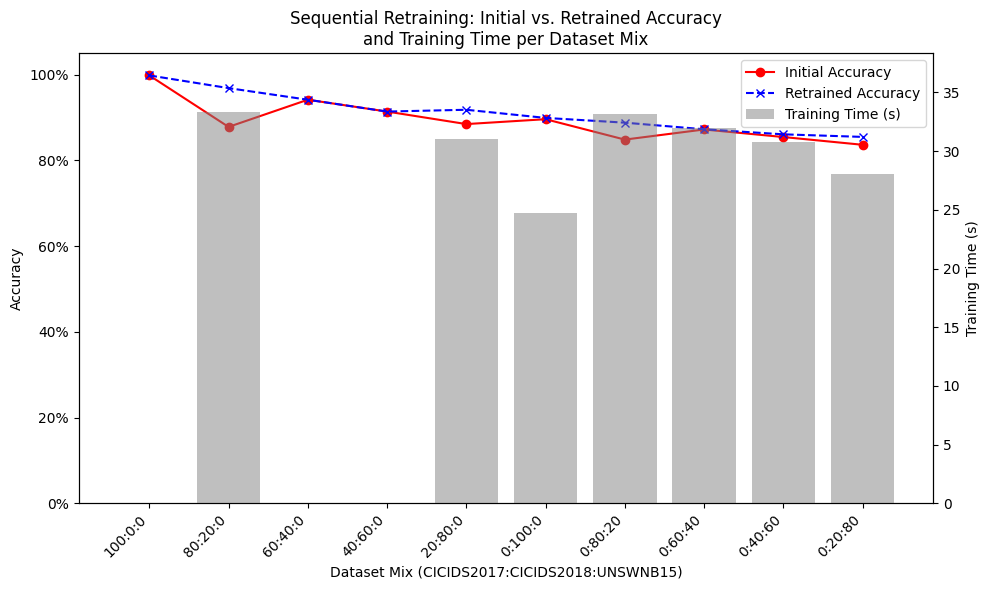

In [40]:
import matplotlib.pyplot as plt

# Data for the new experiment (sequential retraining)
folds = [
    "100:0:0", "80:20:0", "60:40:0", "40:60:0", "20:80:0",
    "0:100:0", "0:80:20", "0:60:40", "0:40:60", "0:20:80"
]
initial_acc   = [0.9980, 0.8779, 0.9413, 0.9137, 0.8845, 0.8959, 0.8483, 0.8719, 0.8543, 0.8362]
retrained_acc = [0.9980, 0.9684, 0.9413, 0.9137, 0.9179, 0.8989, 0.8878, 0.8724, 0.8606, 0.8546]
train_time    = [0.00,   33.35,  0.00,   0.00,   31.07,  24.73,  33.18,  31.95,  30.74,  28.05]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bar chart for training time
bars = ax2.bar(folds, train_time, color='gray', alpha=0.5, label='Training Time (s)')

# Line plots for accuracy
line1, = ax1.plot(folds, initial_acc, color='red',    marker='o', linestyle='-',  label='Initial Accuracy')
line2, = ax1.plot(folds, retrained_acc, color='blue', marker='x', linestyle='--', label='Retrained Accuracy')

# Axis labels and limits
ax1.set_xlabel('Dataset Mix (CICIDS2017:CICIDS2018:UNSWNB15)')
ax1.set_ylabel('Accuracy', color='black')
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax2.set_ylabel('Training Time (s)', color='black')
ax2.set_ylim(0, max(train_time) + 5)

# Rotate x-ticks
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Legends
lines = [line1, line2, bars]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Sequential Retraining: Initial vs. Retrained Accuracy\nand Training Time per Dataset Mix')
plt.tight_layout()
plt.show()


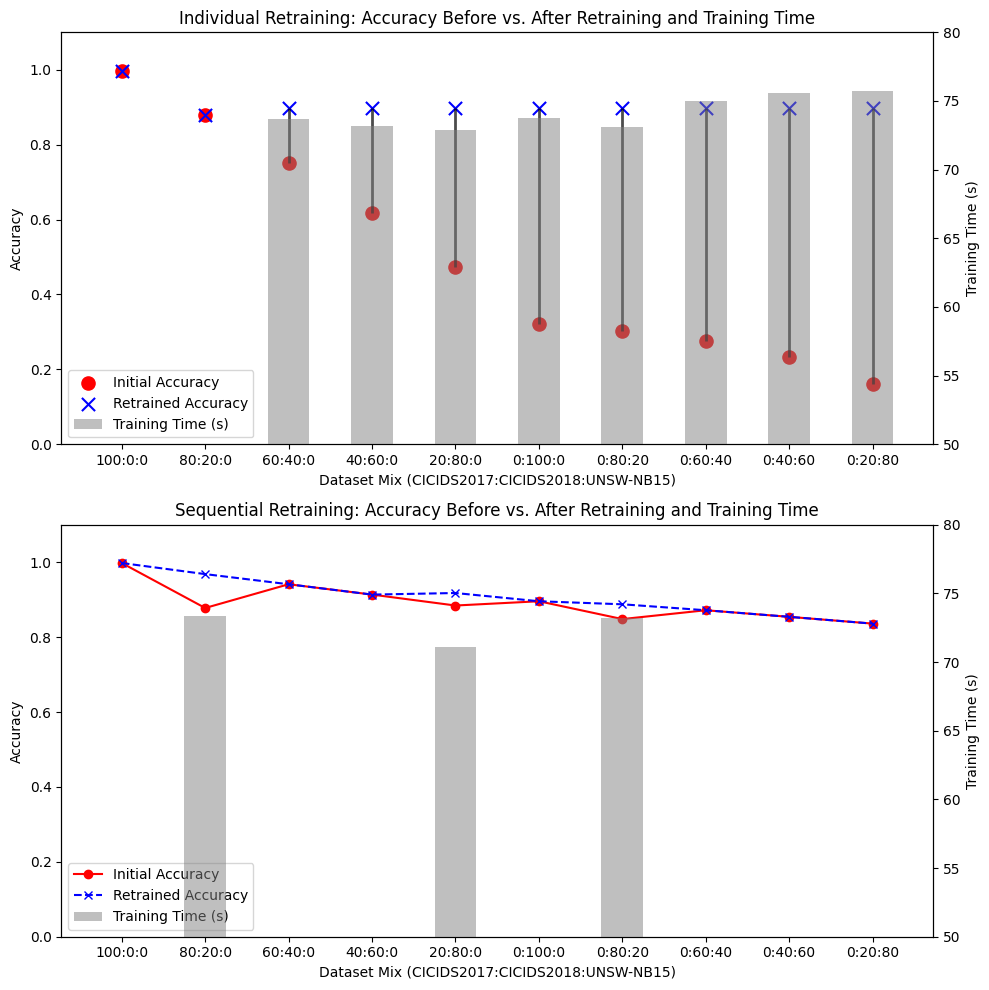

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Shared Data
folds = [
    "100:0:0", "80:20:0", "60:40:0", "40:60:0", "20:80:0",
    "0:100:0", "0:80:20", "0:60:40", "0:40:60", "0:20:80"
]
x = np.arange(len(folds))

# Top: Individual Retraining
init_acc_top   = [0.9980, 0.8779, 0.7515, 0.6167, 0.4743, 0.3207, 0.3029, 0.2749, 0.2341, 0.1600]
retrain_top    = [0.9980, 0.8779, 0.8987, 0.8984, 0.8987, 0.8982, 0.8980, 0.8986, 0.8987, 0.8981]
train_time_top = [0.00,   0.00,   63.68,  63.15,  62.89,  63.75,  63.07,  64.99,  65.55,  65.74]

# Bottom: Sequential Retraining
init_acc_bot   = [0.9980, 0.8779, 0.9413, 0.9137, 0.8845, 0.8959, 0.8483, 0.8719, 0.8543, 0.8362]
retrain_bot    = [0.9980, 0.9684, 0.9413, 0.9137, 0.9179, 0.8959, 0.8878, 0.8719, 0.8543, 0.8362]
train_time_bot = [0.00,   63.35,  0.00,   0.00,   61.07,  0.00,  63.18,  0.00,  0.00,  0.00]

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 10))
ax2 = ax1.twinx()
ax4 = ax3.twinx()

# ---- Top Plot: Individual Retraining ----
ax2.bar(x, train_time_top, color='gray', alpha=0.5, width=0.5, label='Training Time (s)')
for i in range(len(folds)):
    ax1.vlines(x[i], init_acc_top[i], retrain_top[i], color='black', alpha=0.7, linewidth=2)
ax1.scatter(x, init_acc_top, color='red', marker='o', s=90, label='Initial Accuracy')
ax1.scatter(x, retrain_top, color='blue', marker='x', s=90, label='Retrained Accuracy')
ax1.set_ylabel('Accuracy')
ax2.set_ylabel('Training Time (s)')
ax1.set_xlabel('Dataset Mix (CICIDS2017:CICIDS2018:UNSW-NB15)')
ax1.set_xticks(x)
ax1.set_xticklabels(folds, rotation=0)
ax1.set_ylim(0, 1.1)
ax2.set_ylim(50, 70)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
ax1.set_title('Individual Retraining: Accuracy Before vs. After Retraining and Training Time')

# ---- Bottom Plot: Sequential Retraining ----
bars = ax4.bar(x, train_time_bot, color='gray', alpha=0.5, width=0.5, label='Training Time (s)')
line1, = ax3.plot(x, init_acc_bot, color='red', marker='o', label='Initial Accuracy')
line2, = ax3.plot(x, retrain_bot, color='blue', marker='x', linestyle='--', label='Retrained Accuracy')
ax3.set_ylabel('Accuracy')
ax4.set_ylabel('Training Time (s)')
ax3.set_xlabel('Dataset Mix (CICIDS2017:CICIDS2018:UNSW-NB15)')
ax3.set_xticks(x)
ax3.set_xticklabels(folds)
ax3.set_ylim(0, 1.1)
ax4.set_ylim(50,70)
lines = [line1, line2, bars]
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='lower left')
ax3.set_title('Sequential Retraining: Accuracy Before vs. After Retraining and Training Time')

plt.tight_layout()
plt.savefig('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/retraining_comparison.png', dpi=500)


In [35]:
#get accuracy using the model stacked clf and the Y test set
accuracy = stacked_clf.score(X_test, y_test)
print(f"Model accuracy: {accuracy:.2f}")

Model accuracy: 0.98


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [24]:
import joblib
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# Threshold below which we consider accuracy to have “dropped”
ACCURACY_THRESHOLD = 0.80

# 1. Load the existing stacked model
model_filename = '/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/stacked_model.pkl'
stacked_clf = joblib.load(model_filename)
print("Model loaded successfully.")
print(stacked_clf)

# 2. Evaluate on the new test set
accuracy = stacked_clf.score(X_test, y_test)
print(f"Model accuracy on new data: {accuracy:.2f}")

# 3. If accuracy drops below threshold, retrain on X_train, y_train
if accuracy < ACCURACY_THRESHOLD:
    print(f"Accuracy {accuracy:.2f} < {ACCURACY_THRESHOLD:.2f}. Retraining model...")

    params = {
    'min_gain_to_split': 0.1,  # Lowering the threshold for splits
    'min_child_samples': 20,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 30,    # Ensures enough data per leaf
    'num_leaves': 40,
    'max_depth': 15,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,  # Using a fraction of features to prevent overfitting
    'bagging_fraction': 0.8,  # Using a fraction of data to prevent overfitting
    'bagging_freq': 5,  # Perform bagging every iteration
    'random_state': 0,
    'verbose': -1
    }

    # a) Recreate the stacking pipeline (replace with your original base/stacker models)
    base_learners = [
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, criterion='gini', max_features='sqrt')),
        ('lgb', lgb.LGBMClassifier(**params))
    ]
    lr = LogisticRegression(max_iter=20000, C=1.0, penalty='l2', solver='lbfgs', random_state=0)
    meta_learner = lr
    
    # b) Build a new pipeline including scaling + stacking
    #    (Assumes X_train is already the appropriate feature set)
    scaler = StandardScaler()
    stacking = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1,
        passthrough=True
    )

    # Combine scaling and stacking into a single Pipeline
    retrain_pipeline = Pipeline([
        ('scaler', scaler),
        ('stacking', stacking)
    ])

    # c) Fit on the new(train) data
    retrain_pipeline.fit(X_train, y_train)
    new_accuracy = retrain_pipeline.score(X_test, y_test)
    print(f"Retrained model accuracy: {new_accuracy:.2f}")

    # d) Save the newly trained model back to disk
    joblib.dump(retrain_pipeline, model_filename)
    print(f"Retrained model saved to {model_filename}")

else:
    print("Accuracy is above threshold—no retraining needed.")


Model loaded successfully.
Pipeline(steps=[('scaler', StandardScaler()),
                ('stacking',
                 StackingClassifier(cv=5,
                                    estimators=[('rf',
                                                 RandomForestClassifier(max_depth=15,
                                                                        n_estimators=200)),
                                                ('lgb',
                                                 LGBMClassifier(bagging_fraction=0.8,
                                                                bagging_freq=5,
                                                                feature_fraction=0.8,
                                                                learning_rate=0.05,
                                                                max_depth=15,
                                                                min_data_in_leaf=30,
                                                                min_

/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
